# Part 1 — YOLOX + OC-SORT Baseline

## Goal

Run a no-training, CPU-only tracking-by-detection baseline on exactly one
SportsMOT football sequence: `v_gQNyhv8y0QY_c013`.

The source is read directly from its original `img1` image directory. No input
video is stitched or substituted. YOLOX-S detections are cached once and then
passed to OC-SORT. HOTA, DetA, AssA, IDF1, MOTA, FP, FN, IDs, and Frag are
computed from the supplied MOT ground truth.

## Experimental invariant

This notebook and Part 2 must use the same immutable YOLOX cache. Therefore a
difference between the two tracking results can only come from the tracker and
the cut-aware ReID logic, not from a different detector output.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path(r"D:\Bunker\BaseCamp\SceneCut Aware tracking")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from scenecut_tracking.config import load_config
from scenecut_tracking.detection_cache import DetectionCache, build_detection_cache
from scenecut_tracking.evaluation import evaluate_mot
from scenecut_tracking.frame_source import read_source_metadata
from scenecut_tracking.runner import run_video

CONFIG = load_config(PROJECT_ROOT / "configs" / "default.yaml")
SEQUENCE_ROOT = PROJECT_ROOT / "data" / "SportsMOT-Example" / "dataset" / "train" / "v_gQNyhv8y0QY_c013"
GROUND_TRUTH_PATH = SEQUENCE_ROOT / "gt" / "gt.txt"
DETECTION_CACHE_PATH = PROJECT_ROOT / "outputs" / "detections" / "sportsmot_c013_yolox_s_cpu.npz"

assert SEQUENCE_ROOT.is_dir(), SEQUENCE_ROOT
assert GROUND_TRUTH_PATH.is_file(), GROUND_TRUTH_PATH
assert CONFIG["detector"]["backend"] == "yolox"
assert CONFIG["detector"]["device"] == "cpu"
assert CONFIG["reid"]["device"] == "cpu"

metadata = read_source_metadata(SEQUENCE_ROOT)
print(metadata.to_dict())

{'path': 'D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\data\\SportsMOT-Example\\dataset\\train\\v_gQNyhv8y0QY_c013', 'fingerprint': '28a99dd6a303e7d3ae397304070694b4e0d7b9608cee58935afc7ec3c42759e7', 'frame_count': 875, 'width': 1280, 'height': 720, 'fps': 25.0}


## 1. Validate the selected source

The expected sequence has 875 frames, 1280 × 720 resolution, and a declared
frame rate of 25 FPS. Its provided `gt/gt.txt` file is the only tracking ground
truth used here.

In [2]:
assert metadata.frame_count == 875
assert metadata.width == 1280 and metadata.height == 720
assert metadata.fps == 25.0
print(f"Source: {SEQUENCE_ROOT}")
print(f"Frames: {metadata.frame_count}; FPS: {metadata.fps}; size: {metadata.width}×{metadata.height}")

Source: D:\Bunker\BaseCamp\SceneCut Aware tracking\data\SportsMOT-Example\dataset\train\v_gQNyhv8y0QY_c013
Frames: 875; FPS: 25.0; size: 1280×720


## 2. Load the frozen YOLOX detections

`RUN_EXPERIMENT=False` keeps this notebook fast and opens the executed real-run
artifacts. Set it to `True` only when you intentionally want to rebuild the
cache and rerun the full baseline on CPU.

In [3]:
RUN_EXPERIMENT = False
BASELINE_OUTPUT = PROJECT_ROOT / "outputs" / "baseline" / "sportsmot_c013_yolox_ocsort_cpu"

if RUN_EXPERIMENT or not DETECTION_CACHE_PATH.exists():
    from scenecut_tracking.detector import YoloPersonDetector
    detector = YoloPersonDetector(CONFIG["detector"], PROJECT_ROOT)
    cache = build_detection_cache(SEQUENCE_ROOT, detector, CONFIG["detector"])
    cache.save(DETECTION_CACHE_PATH)
else:
    cache = DetectionCache.load(DETECTION_CACHE_PATH)

cache.validate_source(SEQUENCE_ROOT)
print(json.dumps(cache.metadata, indent=2))

{
  "schema_version": 2,
  "video": {
    "path": "D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\data\\SportsMOT-Example\\dataset\\train\\v_gQNyhv8y0QY_c013",
    "fingerprint": "28a99dd6a303e7d3ae397304070694b4e0d7b9608cee58935afc7ec3c42759e7",
    "frame_count": 875,
    "width": 1280,
    "height": 720,
    "fps": 25.0
  },
  "detector": {
    "backend": "yolox",
    "model": "yolox_s",
    "weights": "yolox_s.pth",
    "confidence": 0.05,
    "iou": 0.45,
    "image_size": 640,
    "person_class": 0,
    "device": "cpu"
  },
  "runtime": {
    "elapsed_seconds": 463.21023980000246,
    "processing_fps": 1.8889910559356236,
    "detection_rows": 14239
  }
}


## 3. Run OC-SORT

OC-SORT receives the cached `[x1, y1, x2, y2, confidence, class]` detections.
It maintains short-term Kalman state and uses observation-centric association.

In [4]:
if RUN_EXPERIMENT or not (BASELINE_OUTPUT / "paper_metrics.json").exists():
    baseline_summary = run_video(
        mode="baseline",
        video_path=SEQUENCE_ROOT,
        detection_cache_path=DETECTION_CACHE_PATH,
        output_dir=BASELINE_OUTPUT,
        config=CONFIG,
        project_root=PROJECT_ROOT,
    )
    baseline_metrics = evaluate_mot(GROUND_TRUTH_PATH, BASELINE_OUTPUT / "tracks_mot.txt")
    (BASELINE_OUTPUT / "paper_metrics.json").write_text(json.dumps(baseline_metrics, indent=2))
else:
    baseline_summary = json.loads((BASELINE_OUTPUT / "metrics.json").read_text())
    baseline_metrics = json.loads((BASELINE_OUTPUT / "paper_metrics.json").read_text())

print("Runtime summary")
print(json.dumps(baseline_summary, indent=2))
print()
print("Paper-aligned tracking metrics")
print(json.dumps(baseline_metrics, indent=2))

Runtime summary
{
  "mode": "baseline",
  "frames": 875,
  "source_fps": 25.0,
  "processing_fps": 16.108323011993967,
  "elapsed_seconds": 54.319745100001455,
  "track_rows": 2853,
  "unique_global_ids": 507,
  "detected_scene_cuts": 0,
  "cut_frames": [],
  "accepted_recoveries": 0,
  "average_recovery_similarity": null,
  "annotated_video": "D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\outputs\\baseline\\sportsmot_c013_yolox_ocsort_cpu\\annotated_baseline.mp4",
  "tracks_mot": "D:\\Bunker\\BaseCamp\\SceneCut Aware tracking\\outputs\\baseline\\sportsmot_c013_yolox_ocsort_cpu\\tracks_mot.txt"
}

Paper-aligned tracking metrics
{
  "HOTA": 0.20902481992110222,
  "DetA": 0.12294314398921138,
  "AssA": 0.38464486421965177,
  "IDF1": 0.05965697240865026,
  "MOTA": -26.948943828739225,
  "FP": 2849,
  "FN": 10553,
  "IDs": 0,
  "Frag": 0,
  "GT_detections": 10557,
  "Predicted_detections": 2853
}


## 4. Inspect the completed artifacts

The outputs below are saved by the completed full-sequence run. The detector is
the bottleneck in this no-training setup: COCO-pretrained YOLOX-S has weak
recall on the sequence's small, distant players. That limitation is separate
from OC-SORT association quality.

D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\baseline\sportsmot_c013_yolox_ocsort_cpu\active_identities_over_time.png


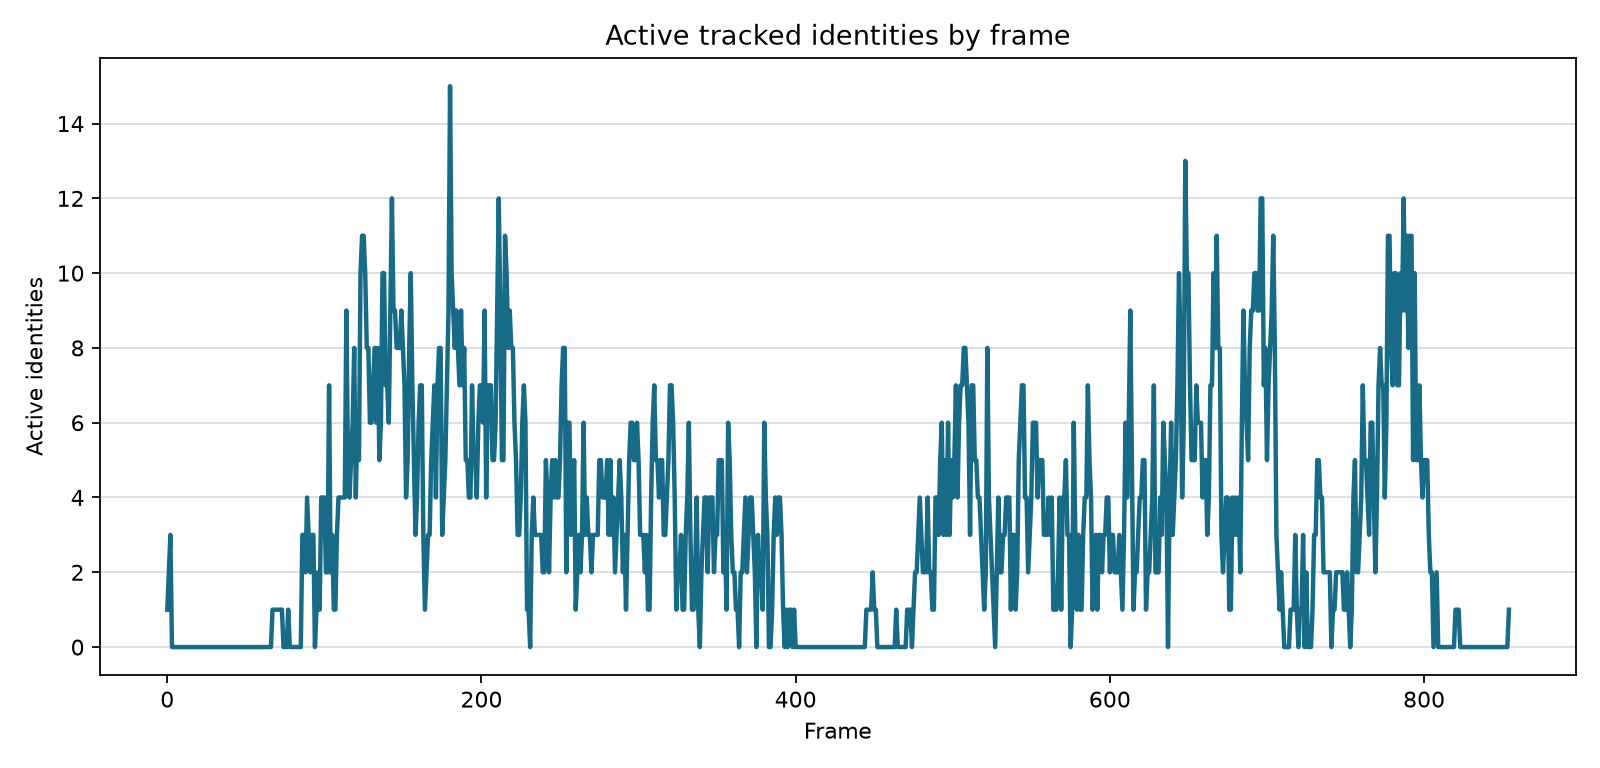

D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\baseline\sportsmot_c013_yolox_ocsort_cpu\track_duration_distribution.png


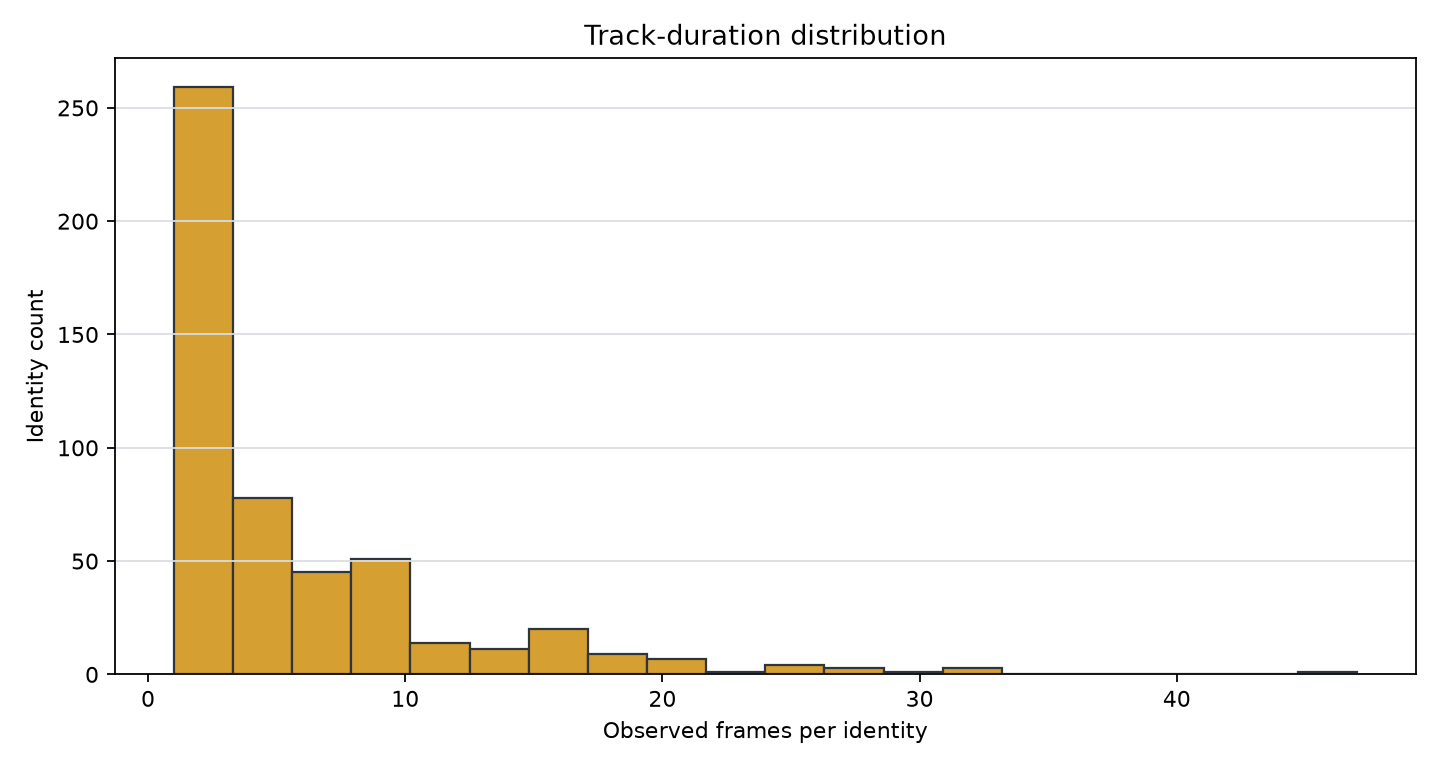

In [5]:
from IPython.display import Image, display

for name in ["active_identities_over_time.png", "track_duration_distribution.png"]:
    path = BASELINE_OUTPUT / name
    print(path)
    display(Image(filename=str(path)))

## Takeaway

This is a valid real SportsMOT measurement, but it is not a strong football
tracking result: the frozen generic YOLOX detector misses most annotated
athletes. Do not claim that the low HOTA/MOTA values mean OC-SORT itself is
wrong. The experiment establishes the baseline under the stated no-training
constraint.